In [20]:

%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

import matplotlib.pyplot as plt
import numpy as np

In [21]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_layers=[128, 64], dropout=0.0):
        super().__init__()
        layers = []
        last_size = input_size
        for size in hidden_layers:
            layers.append(nn.Linear(last_size, size))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            last_size = size
        layers.append(nn.Linear(last_size, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

In [22]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [23]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for data, targets in loader:
        data, targets = data.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
    return total_loss / total, correct / total

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for data, targets in loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            loss = criterion(outputs, targets)
            total_loss += loss.item() * data.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
    return total_loss / total, correct / total

In [24]:
def experiment(hidden_layers, dropout, weight_decay, epochs=20, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MLP(hidden_layers=hidden_layers, dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    best_model_state = None

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict()

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} Acc={train_acc:.4f} | Val Loss={val_loss:.4f} Acc={val_acc:.4f}")

    model.load_state_dict(best_model_state)
    return model, history

In [25]:
def plot_learning_curves(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title} - Loss')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.show()

In [26]:
def evaluate_model(model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            _, preds = torch.max(outputs, 1)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(all_targets, all_preds, average='macro')
    precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(all_targets, all_preds, average=None)
    conf_matrix = confusion_matrix(all_targets, all_preds)

    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall: {recall_macro:.4f}")
    print(f"Macro F1-Score: {f1_macro:.4f}")
    print("\nPer-class Precision:", precision_per_class)
    print("Per-class Recall:", recall_per_class)
    print("Per-class F1:", f1_per_class)
    print("\nConfusion Matrix:\n", conf_matrix)

    return all_preds, all_targets, conf_matrix

In [27]:
def visualize_misclassifications(model, classes, max_images=15):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    misclassified = []

    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            _, preds = torch.max(outputs, 1)
            mis_idx = (preds != targets).nonzero(as_tuple=False).squeeze()

            if mis_idx.dim() == 0:
                mis_idx = mis_idx.unsqueeze(0)

            for idx in mis_idx:
                img = data[idx].cpu().numpy().squeeze()
                true_label = classes[targets[idx].item()]
                pred_label = classes[preds[idx].item()]
                misclassified.append((img, true_label, pred_label))
                if len(misclassified) >= max_images:
                    break
            if len(misclassified) >= max_images:
                break

    plt.figure(figsize=(12, 8))
    for i, (img, true_label, pred_label) in enumerate(misclassified):
        plt.subplot(3, 5, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f"T: {true_label}\nP: {pred_label}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


Training config 1: {'hidden_layers': [32], 'dropout': 0.0, 'weight_decay': 0}
Epoch 1: Train Loss=0.5651 Acc=0.8028 | Val Loss=0.4646 Acc=0.8316
Epoch 2: Train Loss=0.4251 Acc=0.8491 | Val Loss=0.4260 Acc=0.8477
Epoch 3: Train Loss=0.3895 Acc=0.8604 | Val Loss=0.4310 Acc=0.8465
Epoch 4: Train Loss=0.3680 Acc=0.8666 | Val Loss=0.3863 Acc=0.8609
Epoch 5: Train Loss=0.3509 Acc=0.8734 | Val Loss=0.3917 Acc=0.8612
Epoch 6: Train Loss=0.3369 Acc=0.8769 | Val Loss=0.3862 Acc=0.8633
Epoch 7: Train Loss=0.3253 Acc=0.8807 | Val Loss=0.3838 Acc=0.8651
Epoch 8: Train Loss=0.3149 Acc=0.8851 | Val Loss=0.3615 Acc=0.8737
Epoch 9: Train Loss=0.3067 Acc=0.8884 | Val Loss=0.3825 Acc=0.8646
Epoch 10: Train Loss=0.2992 Acc=0.8911 | Val Loss=0.3632 Acc=0.8711
Epoch 11: Train Loss=0.2921 Acc=0.8923 | Val Loss=0.3823 Acc=0.8660
Epoch 12: Train Loss=0.2879 Acc=0.8949 | Val Loss=0.3716 Acc=0.8694
Epoch 13: Train Loss=0.2813 Acc=0.8973 | Val Loss=0.3600 Acc=0.8753
Epoch 14: Train Loss=0.2736 Acc=0.9006 | Val L

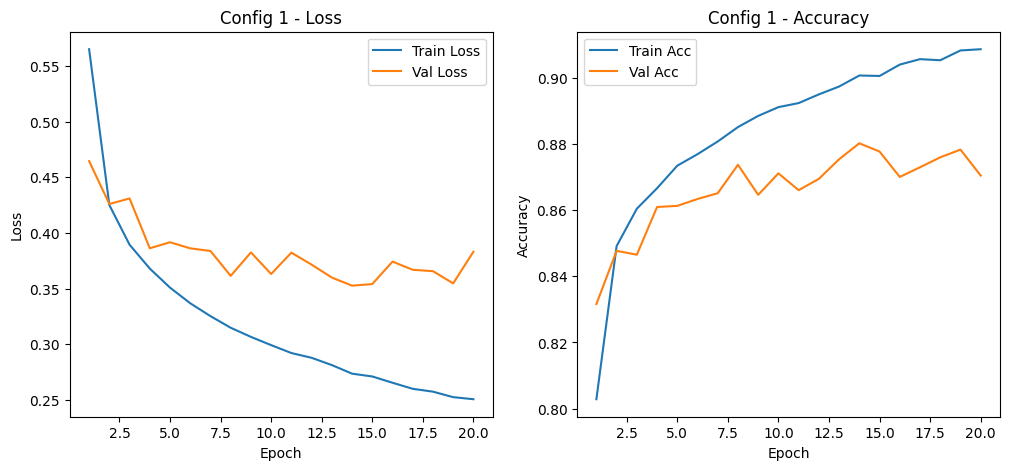


Training config 2: {'hidden_layers': [256, 128, 64], 'dropout': 0.0, 'weight_decay': 0}
Epoch 1: Train Loss=0.5340 Acc=0.8061 | Val Loss=0.4021 Acc=0.8570
Epoch 2: Train Loss=0.3874 Acc=0.8582 | Val Loss=0.3838 Acc=0.8586
Epoch 3: Train Loss=0.3472 Acc=0.8725 | Val Loss=0.3702 Acc=0.8644
Epoch 4: Train Loss=0.3206 Acc=0.8821 | Val Loss=0.3576 Acc=0.8678
Epoch 5: Train Loss=0.2989 Acc=0.8897 | Val Loss=0.3496 Acc=0.8742
Epoch 6: Train Loss=0.2843 Acc=0.8955 | Val Loss=0.3241 Acc=0.8863
Epoch 7: Train Loss=0.2679 Acc=0.9010 | Val Loss=0.3348 Acc=0.8788
Epoch 8: Train Loss=0.2580 Acc=0.9037 | Val Loss=0.3928 Acc=0.8556
Epoch 9: Train Loss=0.2429 Acc=0.9092 | Val Loss=0.3328 Acc=0.8838
Epoch 10: Train Loss=0.2321 Acc=0.9127 | Val Loss=0.3662 Acc=0.8742
Epoch 11: Train Loss=0.2230 Acc=0.9169 | Val Loss=0.3351 Acc=0.8820
Epoch 12: Train Loss=0.2141 Acc=0.9198 | Val Loss=0.3436 Acc=0.8877
Epoch 13: Train Loss=0.2049 Acc=0.9233 | Val Loss=0.3458 Acc=0.8815
Epoch 14: Train Loss=0.1940 Acc=0.92

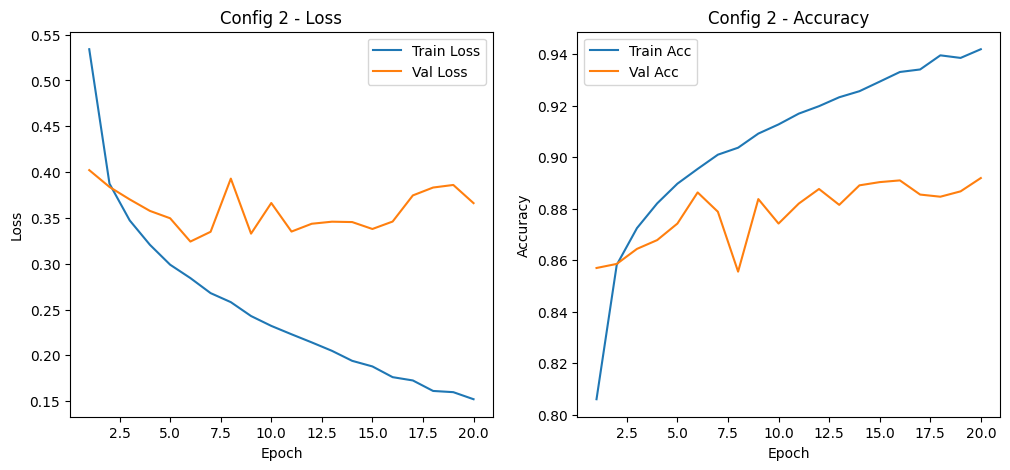


Training config 3: {'hidden_layers': [256, 128, 64], 'dropout': 0.3, 'weight_decay': 0.0001}
Epoch 1: Train Loss=0.6907 Acc=0.7515 | Val Loss=0.4632 Acc=0.8317
Epoch 2: Train Loss=0.4878 Acc=0.8270 | Val Loss=0.4182 Acc=0.8468
Epoch 3: Train Loss=0.4449 Acc=0.8438 | Val Loss=0.3918 Acc=0.8549
Epoch 4: Train Loss=0.4243 Acc=0.8500 | Val Loss=0.3731 Acc=0.8649
Epoch 5: Train Loss=0.4056 Acc=0.8566 | Val Loss=0.3833 Acc=0.8622
Epoch 6: Train Loss=0.3919 Acc=0.8599 | Val Loss=0.3701 Acc=0.8644
Epoch 7: Train Loss=0.3851 Acc=0.8630 | Val Loss=0.3670 Acc=0.8638
Epoch 8: Train Loss=0.3748 Acc=0.8665 | Val Loss=0.3558 Acc=0.8686
Epoch 9: Train Loss=0.3633 Acc=0.8700 | Val Loss=0.3595 Acc=0.8697
Epoch 10: Train Loss=0.3630 Acc=0.8710 | Val Loss=0.3581 Acc=0.8678
Epoch 11: Train Loss=0.3525 Acc=0.8744 | Val Loss=0.3447 Acc=0.8747
Epoch 12: Train Loss=0.3511 Acc=0.8758 | Val Loss=0.3509 Acc=0.8727
Epoch 13: Train Loss=0.3461 Acc=0.8757 | Val Loss=0.3429 Acc=0.8744
Epoch 14: Train Loss=0.3389 Acc

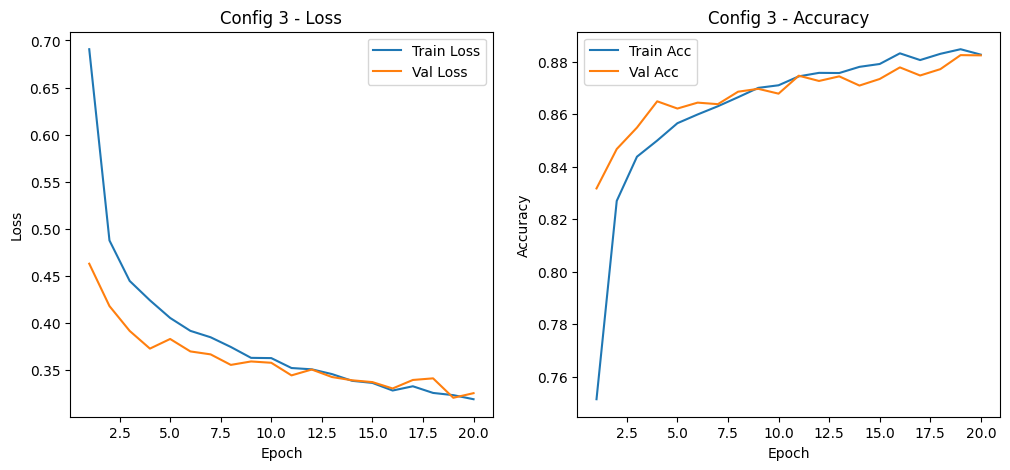


Evaluation on Test Set for Best Model:
Macro Precision: 0.8749
Macro Recall: 0.8748
Macro F1-Score: 0.8733

Per-class Precision: [0.81914894 0.97788945 0.73612297 0.84896811 0.82480958 0.93841642
 0.74969174 0.92352941 0.9668008  0.96380558]
Per-class Recall: [0.847 0.973 0.862 0.905 0.758 0.96  0.608 0.942 0.961 0.932]
Per-class F1: [0.83284169 0.9754386  0.7941041  0.87608906 0.78999479 0.94908552
 0.67145224 0.93267327 0.96389168 0.94763599]

Confusion Matrix:
 [[847   1  22  38   3   2  74   0  13   0]
 [  2 973   2  19   2   0   2   0   0   0]
 [ 11   2 862  11  61   0  52   0   1   0]
 [ 19  14  12 905  26   1  20   0   3   0]
 [  1   2 144  47 758   0  47   0   1   0]
 [  0   0   0   0   0 960   0  30   1   9]
 [150   3 120  37  68   0 608   0  14   0]
 [  0   0   0   0   0  32   0 942   0  26]
 [  4   0   9   9   1   4   7   5 961   0]
 [  0   0   0   0   0  24   1  43   0 932]]


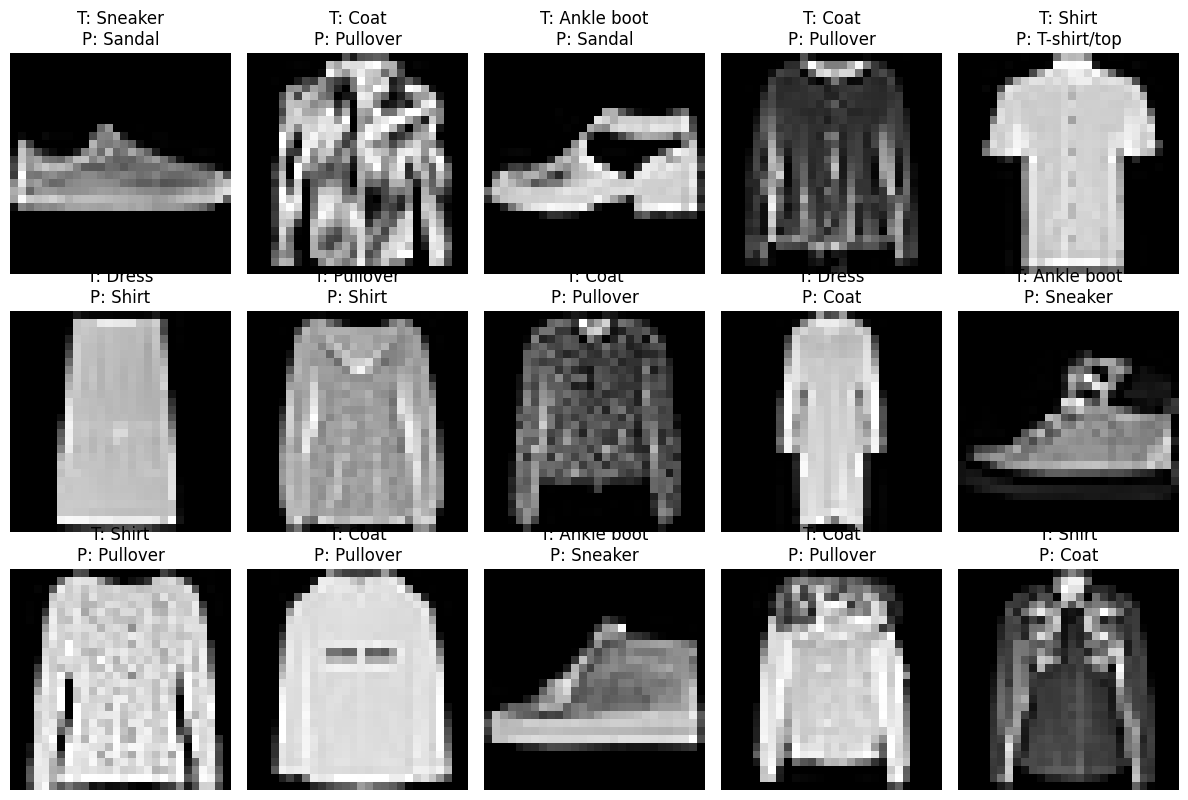

In [28]:
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

configs = [
    {'hidden_layers':[32], 'dropout':0.0, 'weight_decay':0},
    {'hidden_layers':[256, 128, 64], 'dropout':0.0, 'weight_decay':0},
    {'hidden_layers':[256, 128, 64], 'dropout':0.3, 'weight_decay':1e-4}
]

results = []

for i, cfg in enumerate(configs):
    print(f"\nTraining config {i+1}: {cfg}")
    model, history = experiment(cfg['hidden_layers'], cfg['dropout'], cfg['weight_decay'], epochs=20)
    plot_learning_curves(history, f"Config {i+1}")
    results.append((model, history))

best_model = results[-1][0]

print("\nEvaluation on Test Set for Best Model:")
all_preds, all_targets, conf_matrix = evaluate_model(best_model)
visualize_misclassifications(best_model, classes)